In [ ]:
#                       --- This is the context phase enriching our analysis on why incidents happen --- 

In [3]:
# import all neccessary libraries 
import pandas as pd 
import numpy as np 
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns 



In [4]:
db_path = r'C:\Users\dmiracju\Saftey-Risk-Analysis\database\Safety.db' # input the file path and store it as an object

conn = sqlite3.connect(db_path) # inject the object with the file path containing the database and implement it within sqlite3 connection method 

In [5]:
# severity level dataset 
severity = pd.read_sql('SELECT * from dist_severity_level;', conn)

# root cause dataset 
root_cause = pd.read_sql('SELECT * from dist_root_cause;', conn)

# contributing factors 
factors = pd.read_sql('SELECT * from dist_contributing_factors', conn)

In [6]:
#                                       --- Root Cause Analyis (Why risk happens) --- 

In [7]:
root_cause

,root_cause,incidents,ri,dart,pct_of_incidents,pct_of_ri,pct_of_dart
0,improper extension of service life,1,0,0,0.537634,0.000000,0.000000
1,inadequate adjustment/repair,2,0,0,1.075269,0.000000,0.000000
2,inadequate communication between shifts,1,0,0,0.537634,0.000000,0.000000
3,inadequate communication between work groups,1,0,0,0.537634,0.000000,0.000000
4,inadequate communication due to associate turn...,1,1,1,0.537634,2.127660,2.272727
5,inadequate communication of safety requirements,1,0,0,0.537634,0.000000,0.000000
6,inadequate communication of standards or proce...,7,4,4,3.763441,8.510638,9.090909
7,inadequate consideration of ergonomics,2,1,1,1.075269,2.127660,2.272727
8,"inadequate design standards, specifications an...",2,2,2,1.075269,4.255319,4.545455
9,inadequate development / quality of standards ...,1,0,0,0.537634,0.000000,0.000000


In [23]:
root_cause = root_cause.sort_values(by = ['incidents', 'ri', 'dart'], ascending = False) # turn the incident values in descending orfer for futher analyis
root_cause

,root_cause,incidents,ri,dart,pct_of_incidents,pct_of_ri,pct_of_dart,cum_pct_incidents
20,missing standards or procedures,57,18,16,30.645161,38.297872,36.363636,30.645161
12,inadequate implementation of procedure,36,6,6,19.354839,12.765957,13.636364,50.000000
10,inadequate enforcement of procedures,21,4,4,11.290323,8.510638,9.090909,61.290323
16,inadequate recall of training material,16,4,3,8.602151,8.510638,6.818182,69.892473
15,inadequate preventive maintenance,13,2,2,6.989247,4.255319,4.545455,76.881720
22,other,11,1,1,5.913978,2.127660,2.272727,82.795699
6,inadequate communication of standards or proce...,7,4,4,3.763441,8.510638,9.090909,86.559140
8,"inadequate design standards, specifications an...",2,2,2,1.075269,4.255319,4.545455,87.634409
7,inadequate consideration of ergonomics,2,1,1,1.075269,2.127660,2.272727,88.709677
13,inadequate knowledge transfer,2,1,1,1.075269,2.127660,2.272727,89.784946


In [ ]:
# find cumalative percetange (What percentage of incidents do each root causes make up? This tells us which faults we need to focus on the most)
root_cause['cum_pct_incidents'] = root_cause['pct_of_incidents'].cumsum()
root_cause.head(5) # top 5 root causes 

# The top 5 root causes make up 76% of incidents 

,root_cause,incidents,ri,dart,pct_of_incidents,pct_of_ri,pct_of_dart,cum_pct_incidents
20,missing standards or procedures,57,18,16,30.645161,38.297872,36.363636,30.645161
12,inadequate implementation of procedure,36,6,6,19.354839,12.765957,13.636364,50.000000
10,inadequate enforcement of procedures,21,4,4,11.290323,8.510638,9.090909,61.290323
16,inadequate recall of training material,16,4,3,8.602151,8.510638,6.818182,69.892473
15,inadequate preventive maintenance,13,2,2,6.989247,4.255319,4.545455,76.881720


In [ ]:
# Find cumalative percentage for reccuring injuires (What percentage of recuring injuries do each root cause make up) 
root_cause['cum_pct_ri'] = root_cause['pct_of_ri'].cumsum()
root_cause.head(5) # top 5 root causes

# top 5 rootcause make up 72% of reccuring injuires 

,root_cause,incidents,ri,dart,pct_of_incidents,pct_of_ri,pct_of_dart,cum_pct_incidents,cum_pct_ri
20,missing standards or procedures,57,18,16,30.645161,38.297872,36.363636,30.645161,38.297872
12,inadequate implementation of procedure,36,6,6,19.354839,12.765957,13.636364,50.000000,51.063830
10,inadequate enforcement of procedures,21,4,4,11.290323,8.510638,9.090909,61.290323,59.574468
16,inadequate recall of training material,16,4,3,8.602151,8.510638,6.818182,69.892473,68.085106
15,inadequate preventive maintenance,13,2,2,6.989247,4.255319,4.545455,76.881720,72.340426


In [ ]:
# Find cumalative percentage of DART incidents (What percentage of DAYS AWAY, RESTRICTED, TRANSFERED do each root cause make up)
root_cause['cum_pct_dart'] = root_cause['pct_of_dart'].cumsum() 
root_cause.head(5)

# top 5 root cause  make up 70% of DART incidents 

,root_cause,incidents,ri,dart,pct_of_incidents,pct_of_ri,pct_of_dart,cum_pct_incidents,cum_pct_ri,cum_pct_dart
20,missing standards or procedures,57,18,16,30.645161,38.297872,36.363636,30.645161,38.297872,36.363636
12,inadequate implementation of procedure,36,6,6,19.354839,12.765957,13.636364,50.000000,51.063830,50.000000
10,inadequate enforcement of procedures,21,4,4,11.290323,8.510638,9.090909,61.290323,59.574468,59.090909
16,inadequate recall of training material,16,4,3,8.602151,8.510638,6.818182,69.892473,68.085106,65.909091
15,inadequate preventive maintenance,13,2,2,6.989247,4.255319,4.545455,76.881720,72.340426,70.454545


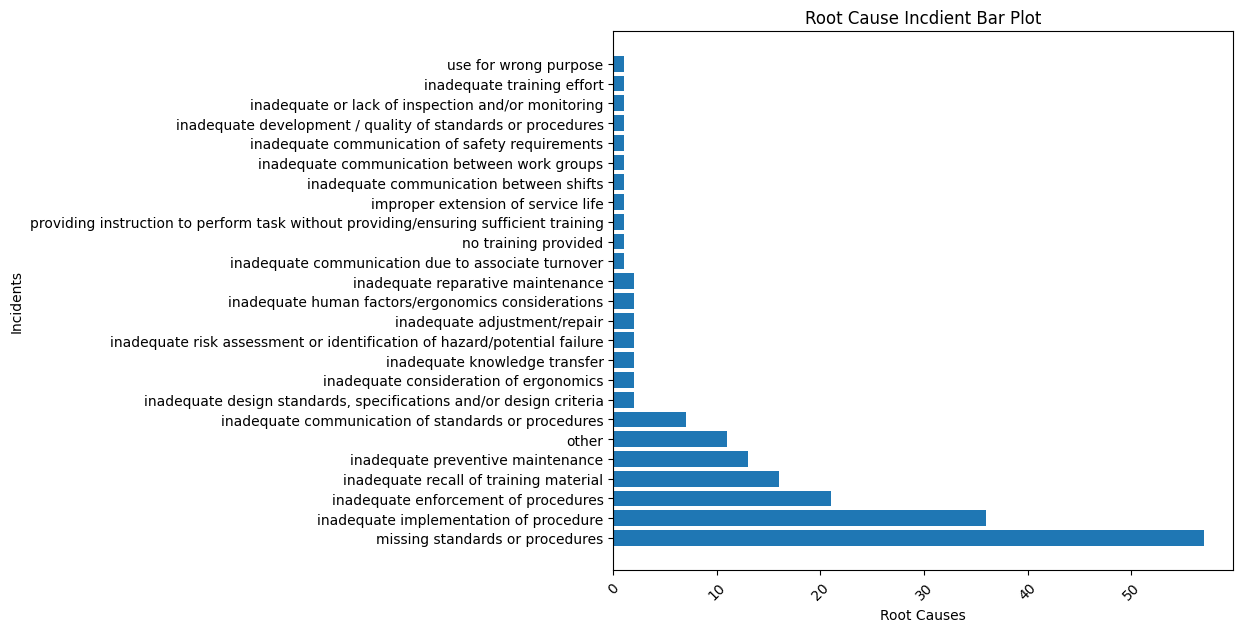

In [ ]:
# visualize bar plot 
plt.figure(figsize=(8,7)) # viusualization size
plt.barh(
    root_cause['root_cause'], 
    root_cause['incidents']
)
plt.title('Root Cause Incident Bar Plot')
plt.xlabel('Root Causes')
plt.ylabel('Incidents')
plt.xticks(rotation = 45)
plt.tight_layout
plt.show()

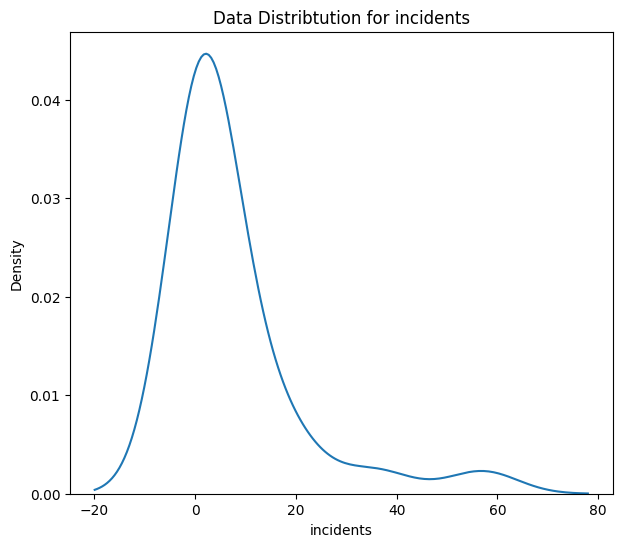

In [ ]:
plt.